#CLUSTERING K-MEANS

K-MEANS CLUSTERING UNTUK DATA TEKS DENGAN METODE ELBOW
Data berhasil dimuat. Jumlah data: 908

Sampel data:
0    halo selamat malam admin anime one piece episo...
1    rating seberapa login susah minta ampun mahal ...
2                         payah dibuka percuma donload
3                                                 good
4                           kualitas flim bagus sekali
5                                                bagus
6    sudah berhenti berlanggan masih saldo sya dikuras
7    assala alaikum terhormat satu satu sangat jele...
8      login susah gilak padahal sandi ama salah valid
9                                           seru drama
Name: Ulasan_Bersih, dtype: object

MEMBUAT REPRESENTASI TEKS (TF-IDF)
Dimensi matriks TF-IDF: (908, 500)
Jumlah fitur (kata unik): 500

MENENTUKAN JUMLAH CLUSTER OPTIMAL

MELAKUKAN METODE ELBOW
Melatih K-Means dengan k=2...
Melatih K-Means dengan k=3...
Melatih K-Means dengan k=4...
Melatih K-Means dengan k=5...
Melatih K-Means dengan k=6.

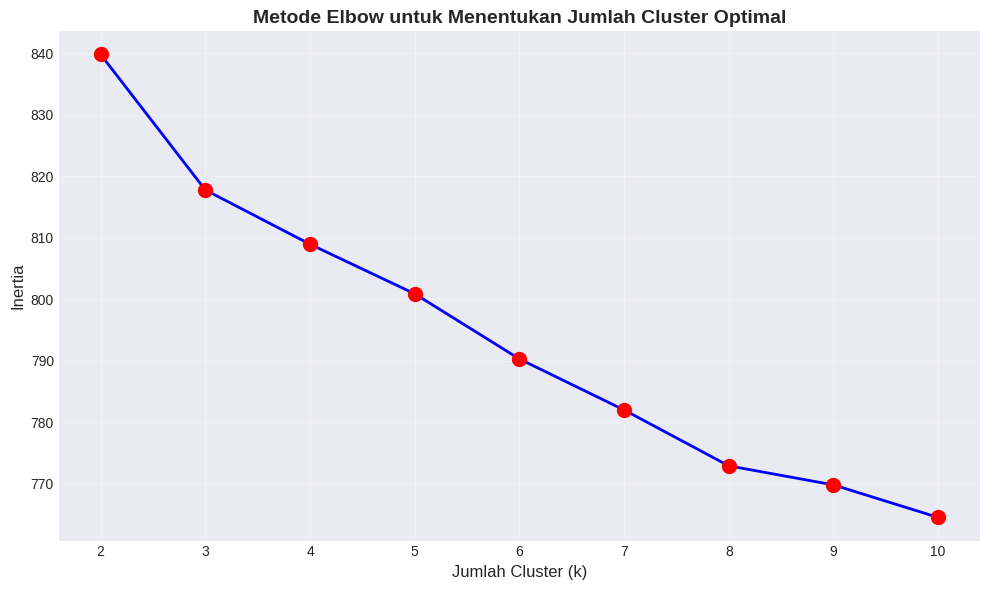


Titik elbow ditemukan di k = 8

Jumlah cluster yang direkomendasikan: 8

MELAKUKAN CLUSTERING DENGAN k=8

Melakukan K-Means clustering dengan 8 cluster...
Clustering selesai.
Inertia: 772.90

ANALISIS HASIL CLUSTERING

Distribusi Data per Cluster:
Cluster 0: 398 data (43.8%)
Cluster 1: 42 data (4.6%)
Cluster 2: 39 data (4.3%)
Cluster 3: 117 data (12.9%)
Cluster 4: 87 data (9.6%)
Cluster 5: 13 data (1.4%)
Cluster 6: 49 data (5.4%)
Cluster 7: 163 data (18.0%)

Top Words per Cluster:

Cluster 0:
  Top words: ribet, daftar, kenapa, sangat, apk, masuk, bayar, loading, keren, buruk

Cluster 1:
  Top words: susah, login, login susah, daftar, daftar susah, masuk, apk, membuat, minta, kenapa

Cluster 2:
  Top words: bagus, sangat, bagus sekali, sangat bagus, sekali, suka, bagus bagus, film bagus, film, nonton

Cluster 3:
  Top words: film, jelek, lengkap, nonton, bagus, banyak, juga, tonton, film lengkap, sudah

Cluster 4:
  Top words: padahal, sudah, padahal sudah, sandi, salah, masuk, lancar

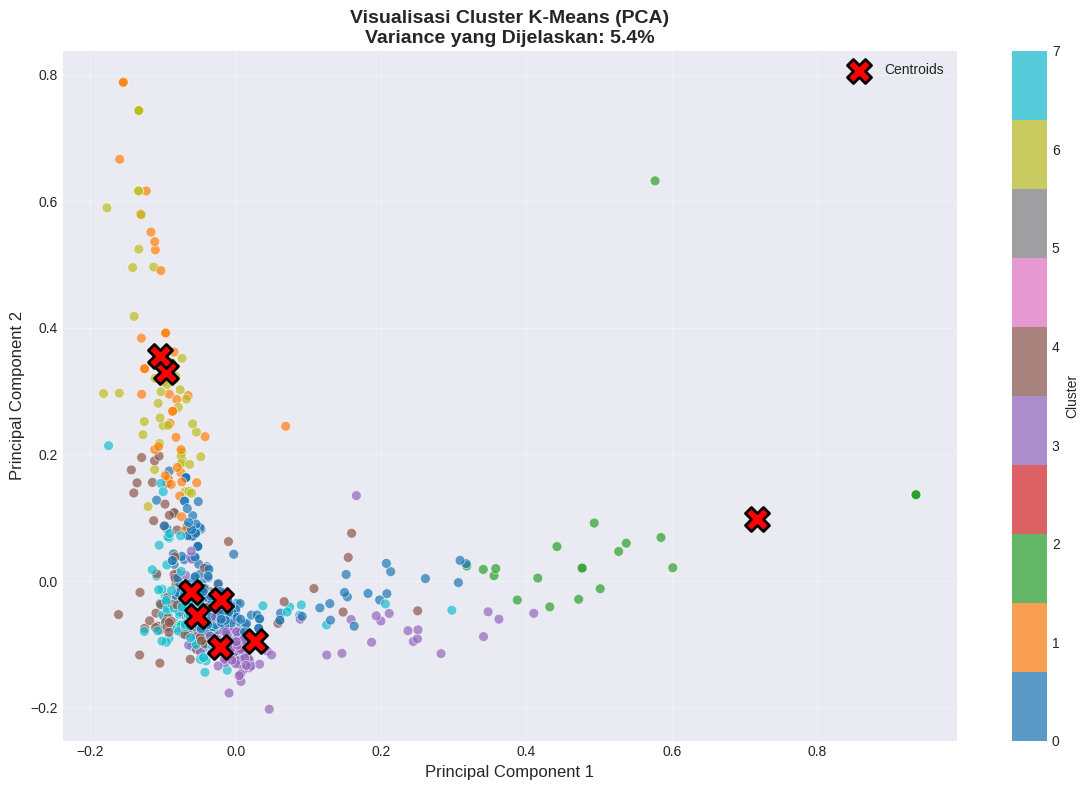

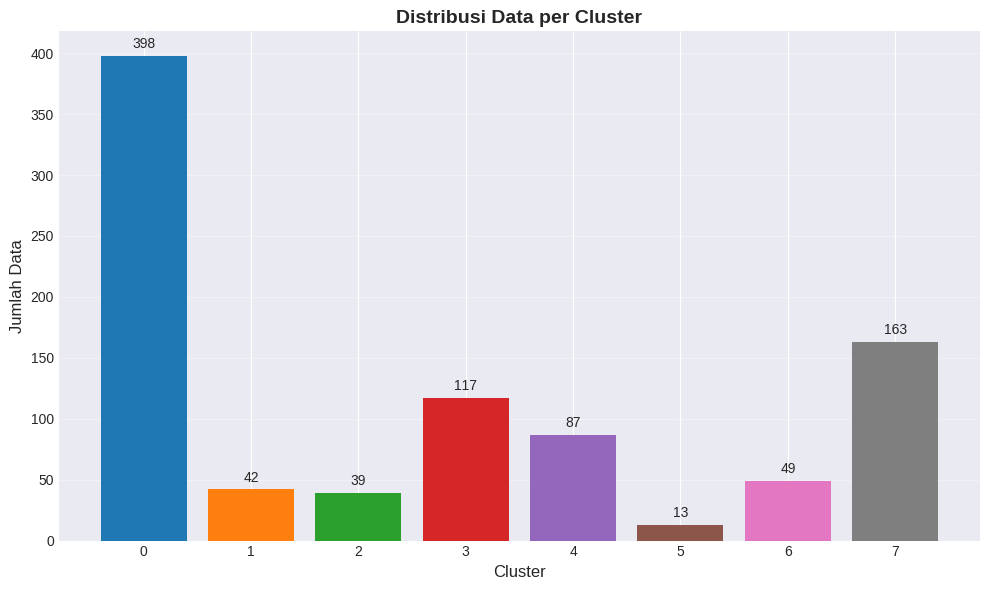


SAMPEL DATA PER CLUSTER

Cluster 0 (Contoh 3 ulasan):
  1. halo selamat malam admin anime one piece episode kenapa mohon ditanggapi terima kasih
  2. payah dibuka percuma donload
  3. assala alaikum terhormat satu satu sangat jelek begitu download coba daftar pakek gmail langsung ara...

Cluster 1 (Contoh 3 ulasan):
  1. rating seberapa login susah minta ampun mahal bayar kocak pantes sepi
  2. login susah gilak padahal sandi ama salah valid
  3. susah

Cluster 2 (Contoh 3 ulasan):
  1. kualitas flim bagus sekali
  2. bagus
  3. bagus

Cluster 3 (Contoh 3 ulasan):
  1. tambahin fitur tonton nanti min fitur daftar pantes cum buat film favorite film
  2. lumay bagus walau masih film pengen nonton sudah bagus film film juga berkualitas
  3. jelek

Cluster 4 (Contoh 3 ulasan):
  1. susah sekali daftar harus membayar padahal nama sudah benar tetap
  2. gambar brebek jelas percuma langgan padahal sudah support wifi gambar brebek kaya kaset kusut recomm...
  3. padahal sudah langgan saldo po

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ==============================================
# 1. LOAD DATA
# ==============================================

def load_data(file_path):
    """Load data dari file CSV"""
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
        print(f"Data berhasil dimuat. Jumlah data: {len(df)}")
        return df
    except UnicodeDecodeError:
        # Coba encoding lain jika UTF-8 gagal
        df = pd.read_csv(file_path, encoding='latin-1')
        print(f"Data berhasil dimuat (latin-1). Jumlah data: {len(df)}")
        return df

# ==============================================
# 2. PREPROCESSING TEKS
# ==============================================

def preprocess_text(text):
    """Fungsi sederhana untuk preprocessing teks"""
    if isinstance(text, str):
        # Konversi ke lowercase
        text = text.lower()
        # Hapus karakter spesial (bisa ditambahkan sesuai kebutuhan)
        # text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        return text
    return ""

def create_tfidf_matrix(documents, max_features=1000):
    """Membuat matriks TF-IDF dari dokumen teks"""

    # Preprocess semua dokumen
    processed_docs = [preprocess_text(doc) for doc in documents]

    # Inisialisasi TF-IDF Vectorizer
    vectorizer = TfidfVectorizer(
        max_features=max_features,  # Jumlah fitur maksimal
        min_df=2,                   # Minimum dokumen yang mengandung kata
        max_df=0.95,                # Maksimum dokumen yang mengandung kata
        stop_words=None,            # Bisa ditambahkan stopwords bahasa Indonesia
        ngram_range=(1, 2)          # Bisa menggunakan unigram dan bigram
    )

    # Transform dokumen menjadi vektor TF-IDF
    tfidf_matrix = vectorizer.fit_transform(processed_docs)

    print(f"Dimensi matriks TF-IDF: {tfidf_matrix.shape}")
    print(f"Jumlah fitur (kata unik): {len(vectorizer.get_feature_names_out())}")

    return tfidf_matrix, vectorizer

# ==============================================
# 3. METODE ELBOW UNTUK MENENTUKAN K OPTIMAL
# ==============================================

def elbow_method(tfidf_matrix, max_k=10):
    """
    Menentukan jumlah cluster optimal menggunakan metode elbow
    """
    print("\n" + "="*50)
    print("MELAKUKAN METODE ELBOW")
    print("="*50)

    inertias = []
    k_values = range(2, max_k + 1)

    for k in k_values:
        print(f"Melatih K-Means dengan k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(tfidf_matrix)
        inertias.append(kmeans.inertia_)

    # Plot elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Jumlah Cluster (k)', fontsize=12)
    plt.ylabel('Inertia', fontsize=12)
    plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Tambahkan titik untuk elbow
    plt.scatter(k_values, inertias, color='red', s=100, zorder=5)

    plt.xticks(k_values)
    plt.tight_layout()
    plt.show()

    return k_values, inertias

def calculate_elbow_point(inertias, k_values):
    """
    Menghitung titik elbow secara matematis
    """
    # Hitung perbedaan inertia
    diff = np.diff(inertias)
    diff_ratio = diff[:-1] / diff[1:]

    # Cari titik dengan ratio terbesar
    elbow_idx = np.argmax(diff_ratio) + 1  # +1 karena diff_ratio lebih pendek
    optimal_k = k_values[elbow_idx]

    print(f"\nTitik elbow ditemukan di k = {optimal_k}")
    return optimal_k

# ==============================================
# 4. CLUSTERING K-MEANS
# ==============================================

def perform_kmeans_clustering(tfidf_matrix, n_clusters, random_state=42):
    """Melakukan clustering K-Means"""
    print(f"\nMelakukan K-Means clustering dengan {n_clusters} cluster...")

    # Inisialisasi dan train K-Means
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=20,      # Jumlah inisialisasi untuk menghindari local optimum
        max_iter=300,   # Iterasi maksimal
        verbose=0       # Non-aktifkan output verbose
    )

    # Fit model
    kmeans.fit(tfidf_matrix)

    # Dapatkan label cluster
    labels = kmeans.labels_

    print(f"Clustering selesai.")
    print(f"Inertia: {kmeans.inertia_:.2f}")

    return kmeans, labels

# ==============================================
# 5. ANALISIS DAN VISUALISASI HASIL
# ==============================================

def analyze_clusters(df, labels, vectorizer, kmeans, top_words=10):
    """Menganalisis dan menampilkan hasil clustering"""

    # Tambahkan label cluster ke dataframe
    df = df.copy()
    df['Cluster'] = labels

    print("\n" + "="*50)
    print("ANALISIS HASIL CLUSTERING")
    print("="*50)

    # Distribusi cluster
    print("\nDistribusi Data per Cluster:")
    cluster_dist = df['Cluster'].value_counts().sort_index()
    for cluster, count in cluster_dist.items():
        percentage = (count / len(df)) * 100
        print(f"Cluster {cluster}: {count} data ({percentage:.1f}%)")

    # Top words per cluster
    print("\nTop Words per Cluster:")
    order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()

    for i in range(len(cluster_dist)):
        print(f"\nCluster {i}:")
        top_words_idx = order_centroids[i, :top_words]
        top_terms = [terms[idx] for idx in top_words_idx]
        print(f"  Top words: {', '.join(top_terms)}")

    return df

def visualize_clusters_pca(tfidf_matrix, labels, kmeans):
    """Visualisasi cluster menggunakan PCA"""

    print("\nMembuat visualisasi 2D dengan PCA...")

    # Reduksi dimensi dengan PCA
    pca = PCA(n_components=2, random_state=42)
    tfidf_dense = tfidf_matrix.toarray()
    reduced_data = pca.fit_transform(tfidf_dense)

    # Hitung variance yang dijelaskan
    explained_variance = pca.explained_variance_ratio_.sum() * 100

    # Buat dataframe untuk plotting
    plot_df = pd.DataFrame({
        'PC1': reduced_data[:, 0],
        'PC2': reduced_data[:, 1],
        'Cluster': labels
    })

    # Plot hasil PCA
    plt.figure(figsize=(12, 8))

    # Scatter plot per cluster
    scatter = plt.scatter(
        plot_df['PC1'],
        plot_df['PC2'],
        c=plot_df['Cluster'],
        cmap='tab10',
        alpha=0.7,
        s=50,
        edgecolors='w',
        linewidth=0.5
    )

    # Plot centroids
    centroids = kmeans.cluster_centers_
    reduced_centroids = pca.transform(centroids)
    plt.scatter(
        reduced_centroids[:, 0],
        reduced_centroids[:, 1],
        marker='X',
        s=300,
        c='red',
        edgecolors='black',
        linewidth=2,
        label='Centroids'
    )

    plt.xlabel(f'Principal Component 1', fontsize=12)
    plt.ylabel(f'Principal Component 2', fontsize=12)
    plt.title(f'Visualisasi Cluster K-Means (PCA)\nVariance yang Dijelaskan: {explained_variance:.1f}%',
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return plot_df

def visualize_cluster_distribution(df):
    """Visualisasi distribusi cluster"""

    plt.figure(figsize=(10, 6))

    # Hitung distribusi
    cluster_counts = df['Cluster'].value_counts().sort_index()

    # Buat bar plot
    bars = plt.bar(
        cluster_counts.index.astype(str),
        cluster_counts.values,
        color=plt.cm.tab10(np.arange(len(cluster_counts)))
    )

    # Tambahkan label jumlah
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height + max(cluster_counts.values) * 0.01,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Jumlah Data', fontsize=12)
    plt.title('Distribusi Data per Cluster', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# ==============================================
# 6. FUNGSI UTAMA
# ==============================================

def main():
    """Fungsi utama untuk menjalankan seluruh proses"""

    print("="*60)
    print("K-MEANS CLUSTERING UNTUK DATA TEKS DENGAN METODE ELBOW")
    print("="*60)

    # 1. Load data
    # Ganti dengan path file Anda
    file_path = "Data Ulasan Bersih.csv"  # Sesuaikan dengan nama file Anda
    df = load_data(file_path)

    # Pastikan kolom 'Ulasan_Bersih' ada
    if 'Ulasan_Bersih' not in df.columns:
        print("Kolom 'Ulasan_Bersih' tidak ditemukan. Kolom yang tersedia:")
        print(df.columns.tolist())
        # Coba gunakan kolom pertama jika ada
        first_col = df.columns[0]
        print(f"Menggunakan kolom pertama: {first_col}")
        df.rename(columns={first_col: 'Ulasan_Bersih'}, inplace=True)

    # Tampilkan sampel data
    print("\nSampel data:")
    print(df['Ulasan_Bersih'].head(10))

    # 2. Preprocessing dan pembuatan TF-IDF
    print("\n" + "="*50)
    print("MEMBUAT REPRESENTASI TEKS (TF-IDF)")
    print("="*50)

    tfidf_matrix, vectorizer = create_tfidf_matrix(
        df['Ulasan_Bersih'].fillna('').tolist(),
        max_features=500  # Anda bisa menyesuaikan ini
    )

    # 3. Metode Elbow untuk menentukan k optimal
    print("\n" + "="*50)
    print("MENENTUKAN JUMLAH CLUSTER OPTIMAL")
    print("="*50)

    k_values, inertias = elbow_method(tfidf_matrix, max_k=10)

    # Hitung titik elbow secara matematis
    optimal_k = calculate_elbow_point(inertias, list(k_values))

    # 4. Konfirmasi jumlah cluster
    print(f"\nJumlah cluster yang direkomendasikan: {optimal_k}")

    # Anda bisa mengubah ini jika ingin mencoba k lain
    final_k = optimal_k

    # 5. Lakukan clustering dengan k yang dipilih
    print("\n" + "="*50)
    print(f"MELAKUKAN CLUSTERING DENGAN k={final_k}")
    print("="*50)

    kmeans_model, labels = perform_kmeans_clustering(tfidf_matrix, n_clusters=final_k)

    # 6. Analisis hasil clustering
    df_with_clusters = analyze_clusters(df, labels, vectorizer, kmeans_model, top_words=10)

    # 7. Visualisasi hasil
    print("\n" + "="*50)
    print("VISUALISASI HASIL CLUSTERING")
    print("="*50)

    # Visualisasi dengan PCA
    plot_df = visualize_clusters_pca(tfidf_matrix, labels, kmeans_model)

    # Visualisasi distribusi cluster
    visualize_cluster_distribution(df_with_clusters)

    # 8. Tampilkan sampel data per cluster
    print("\n" + "="*50)
    print("SAMPEL DATA PER CLUSTER")
    print("="*50)

    for cluster in sorted(df_with_clusters['Cluster'].unique()):
        cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
        print(f"\nCluster {cluster} (Contoh 3 ulasan):")
        for i, (_, row) in enumerate(cluster_data.head(3).iterrows()):
            text = row['Ulasan_Bersih']
            preview = text[:100] + "..." if len(text) > 100 else text
            print(f"  {i+1}. {preview}")

    # 9. Simpan hasil clustering
    output_file = "hasil_clustering K-means.csv"
    df_with_clusters.to_csv(output_file, index=False, encoding='utf-8')
    print(f"\nHasil clustering disimpan ke: {output_file}")

    print("\n" + "="*60)
    print("PROSES CLUSTERING SELESAI")
    print("="*60)

    return df_with_clusters, kmeans_model, vectorizer

# ==============================================
# 7. FUNGSI TAMBAHAN: EVALUASI MODEL
# ==============================================

def evaluate_clustering(tfidf_matrix, labels):
    """Evaluasi kualitas clustering"""

    print("\n" + "="*50)
    print("EVALUASI KUALITAS CLUSTERING")
    print("="*50)

    # Hitung Silhouette Score
    try:
        silhouette_avg = silhouette_score(tfidf_matrix, labels)
        print(f"Silhouette Score: {silhouette_avg:.4f}")

        # Interpretasi silhouette score
        if silhouette_avg > 0.7:
            print("Interpretasi: Struktur clustering kuat.")
        elif silhouette_avg > 0.5:
            print("Interpretasi: Struktur clustering cukup.")
        elif silhouette_avg > 0.25:
            print("Interpretasi: Struktur clustering lemah.")
        else:
            print("Interpretasi: Tidak ada struktur clustering yang signifikan.")

    except Exception as e:
        print(f"Tidak dapat menghitung silhouette score: {e}")

# ==============================================
# 8. JALANKAN PROGRAM
# ==============================================

if __name__ == "__main__":

    # Jalankan fungsi utama
    df_result, kmeans_model, vectorizer = main()

    # Evaluasi clustering (opsional)
    # Note: Silhouette score bisa lambat untuk data besar
    if len(df_result) < 10000:  # Hitung untuk data yang tidak terlalu besar
        tfidf_matrix, _ = create_tfidf_matrix(
            df_result['Ulasan_Bersih'].fillna('').tolist(),
            max_features=500
        )
        evaluate_clustering(tfidf_matrix, df_result['Cluster'].values)

#CLUSTERING TOPIC MODELING

TOPIC MODELING CLUSTERING DENGAN METODE ELBOW
Data berhasil dimuat. Jumlah data: 908
Jumlah data setelah cleaning: 777

Sampel data setelah cleaning:
                                       Ulasan_Bersih  \
0  halo selamat malam admin anime one piece episo...   
1  rating seberapa login susah minta ampun mahal ...   
2                       payah dibuka percuma donload   
4                         kualitas flim bagus sekali   
6  sudah berhenti berlanggan masih saldo sya dikuras   

                                        text_cleaned  
0  halo selamat malam admin anime one piece episo...  
1  rating seberapa login susah minta ampun mahal ...  
2                       payah dibuka percuma donload  
4                         kualitas flim bagus sekali  
6  sudah berhenti berlanggan masih saldo sya dikuras  

MULAI PROSES LDA TOPIC MODELING

LDA TOPIC MODELING DENGAN METODE ELBOW
Dimensi Count matrix: (777, 800)

Menghitung coherence scores untuk berbagai jumlah topics...
Training LDA den

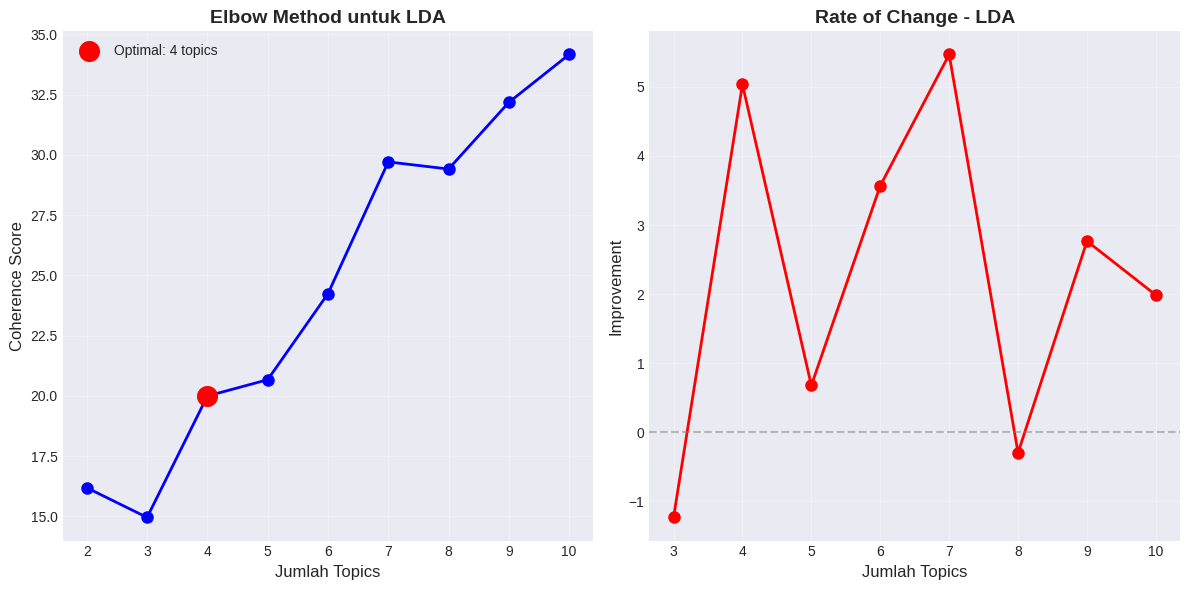


Jumlah topics optimal berdasarkan elbow method: 4

ANALISIS TOPICS

Topic 0:
  Top words: film, nonton, bagus, baru, padahal, sudah, kalau, anime, suka, sangat
  Dokumen representative:
    1. kesel sama film bagus cut dilanjut season banyak malah kli liat rating orng nont...
    2. seminggu sudah dipake tiba balik lama history nonton lama history drama baru dit...

Topic 1:
  Top words: sudah, login, bayar, padahal, masuk, tiba, kenapa, dapat, malah, coba
  Dokumen representative:
    1. kalau nonton harus masuk daftar dulu daftar panjang proses sudah promosi proses ...
    2. membayar langgan pakai gopay saldo gopay sudah terpotong login dikasih link disu...

Topic 2:
  Top words: loading, bahasa, subtitle, indonesia, terus, download, suara, gambar, ingin, buruk
  Dokumen representative:
    1. rizky indonesia bahasa indonesia setiap filem bahasa negara seperti tail pati ba...
    2. wahai pemilik komen sini buk ingin mengkritik ingin meminta hadir kembali kartun...

Topic 3:
  Top 

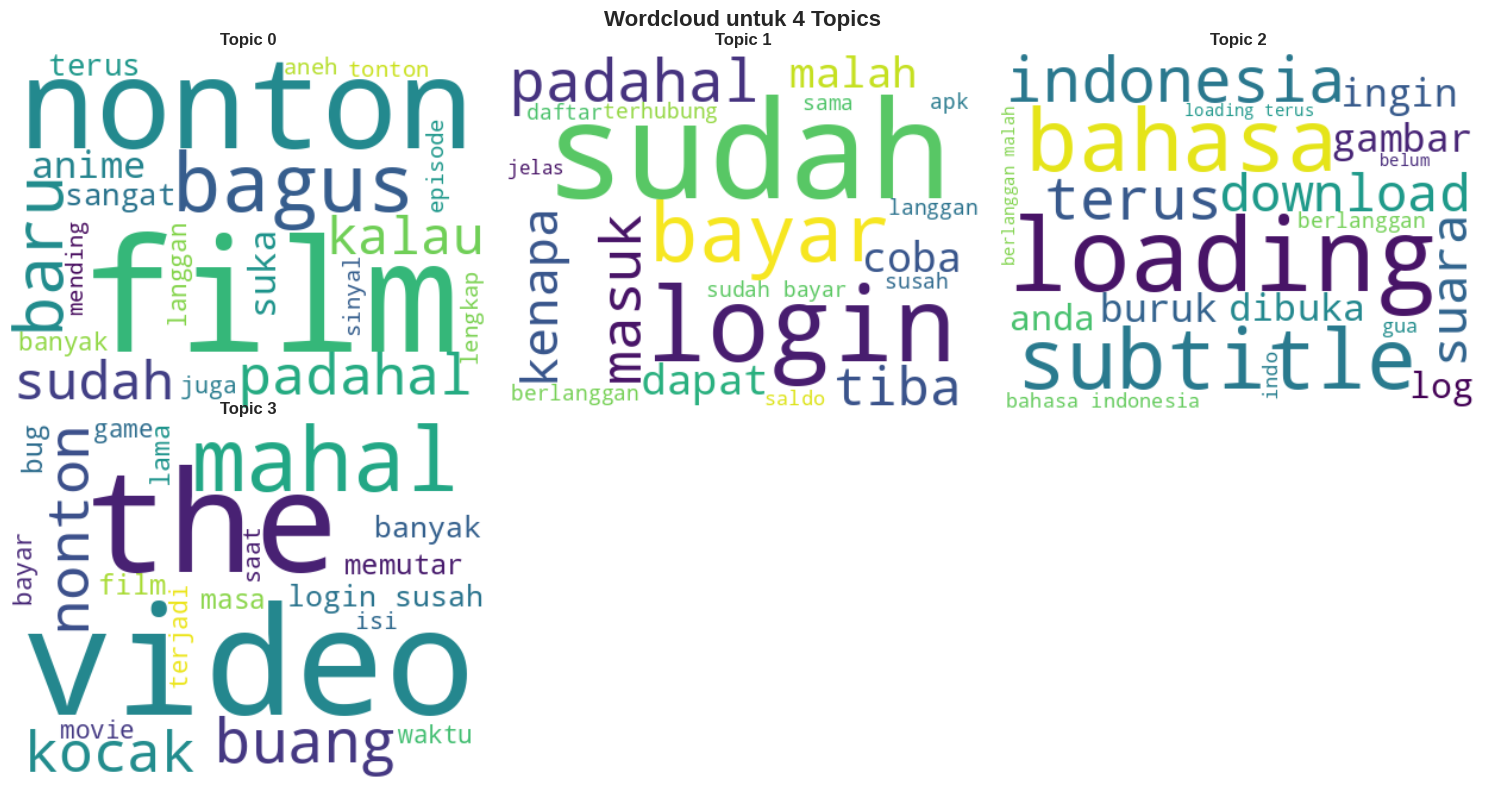

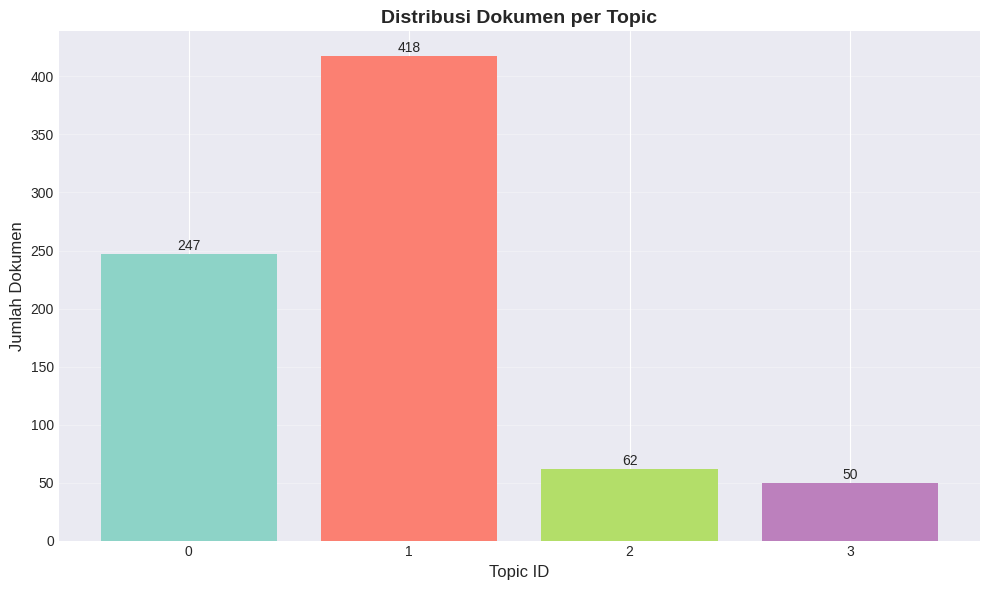


Topic Diversity Score: 0.9333
Average overlap per 10 top words: 0.67

MULAI PROSES NMF TOPIC MODELING

NMF TOPIC MODELING DENGAN METODE ELBOW
Dimensi TF-IDF matrix: (777, 800)

Menghitung coherence scores untuk berbagai jumlah topics...
Training NMF dengan 2 topics...
  Coherence Score: 24.8916
Training NMF dengan 3 topics...
  Coherence Score: 33.8270
Training NMF dengan 4 topics...
  Coherence Score: 34.8667
Training NMF dengan 5 topics...
  Coherence Score: 33.9043
Training NMF dengan 6 topics...
  Coherence Score: 35.6047
Training NMF dengan 7 topics...
  Coherence Score: 35.1811
Training NMF dengan 8 topics...
  Coherence Score: 40.6135
Training NMF dengan 9 topics...
  Coherence Score: 39.9172
Training NMF dengan 10 topics...
  Coherence Score: 37.8450

Mencari jumlah topics optimal...


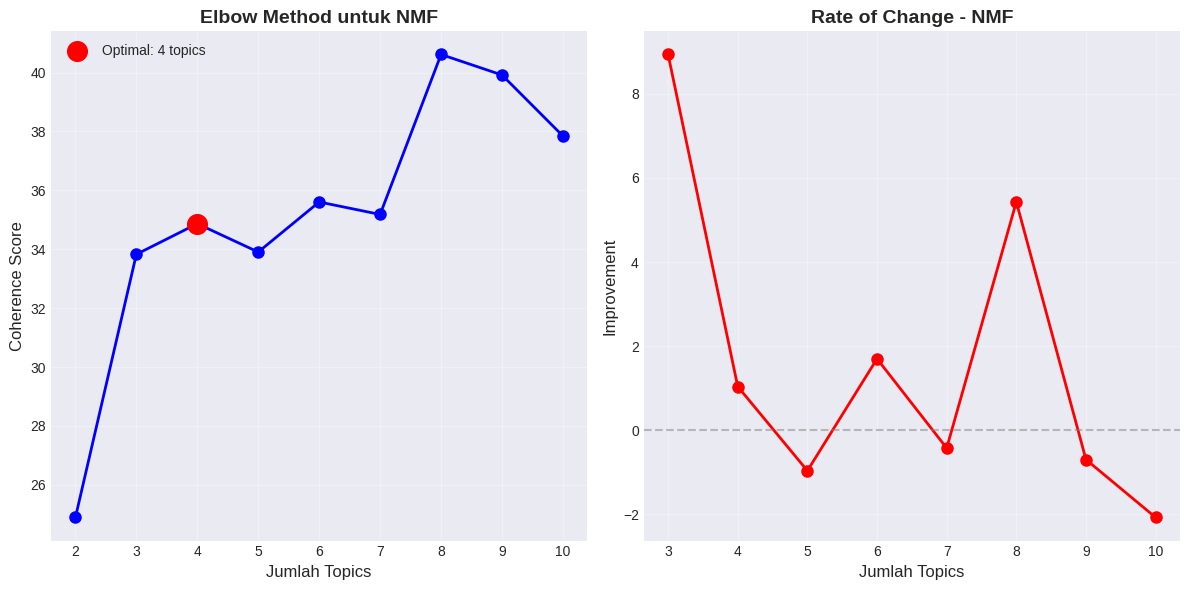


Jumlah topics optimal berdasarkan elbow method: 4

ANALISIS TOPICS

Topic 0:
  Top words: sudah, bayar, padahal, sudah bayar, langgan, padahal sudah, masuk, kenapa, nonton, terus
  Dokumen representative:
    1. sudah bayar malah terus terus daftar bayar padahal sudah jelas jelas sudah bayar...
    2. kenapa setel muter terus padahal sudah bayar tiap langgan

Topic 1:
  Top words: film, bagus, sangat, nonton, lengkap, banyak, sangat bagus, suka, film lengkap, film bagus
  Dokumen representative:
    1. sangat bagus buat nonton film sangat banyak menghibur bagus barang bro
    2. sangat bagus film film lengkap seru kasih bintang

Topic 2:
  Top words: login, susah, apk, masuk, login susah, susah login, daftar susah, membuat, kenapa, buat
  Dokumen representative:
    1. login susah
    2. aduh login kakak

Topic 3:
  Top words: ribet, daftar, daftar ribet, harus, cara daftar, daftar susah, cara, bayar, harus bayar, anjir
  Dokumen representative:
    1. daftar ribet
    2. daftar ribet

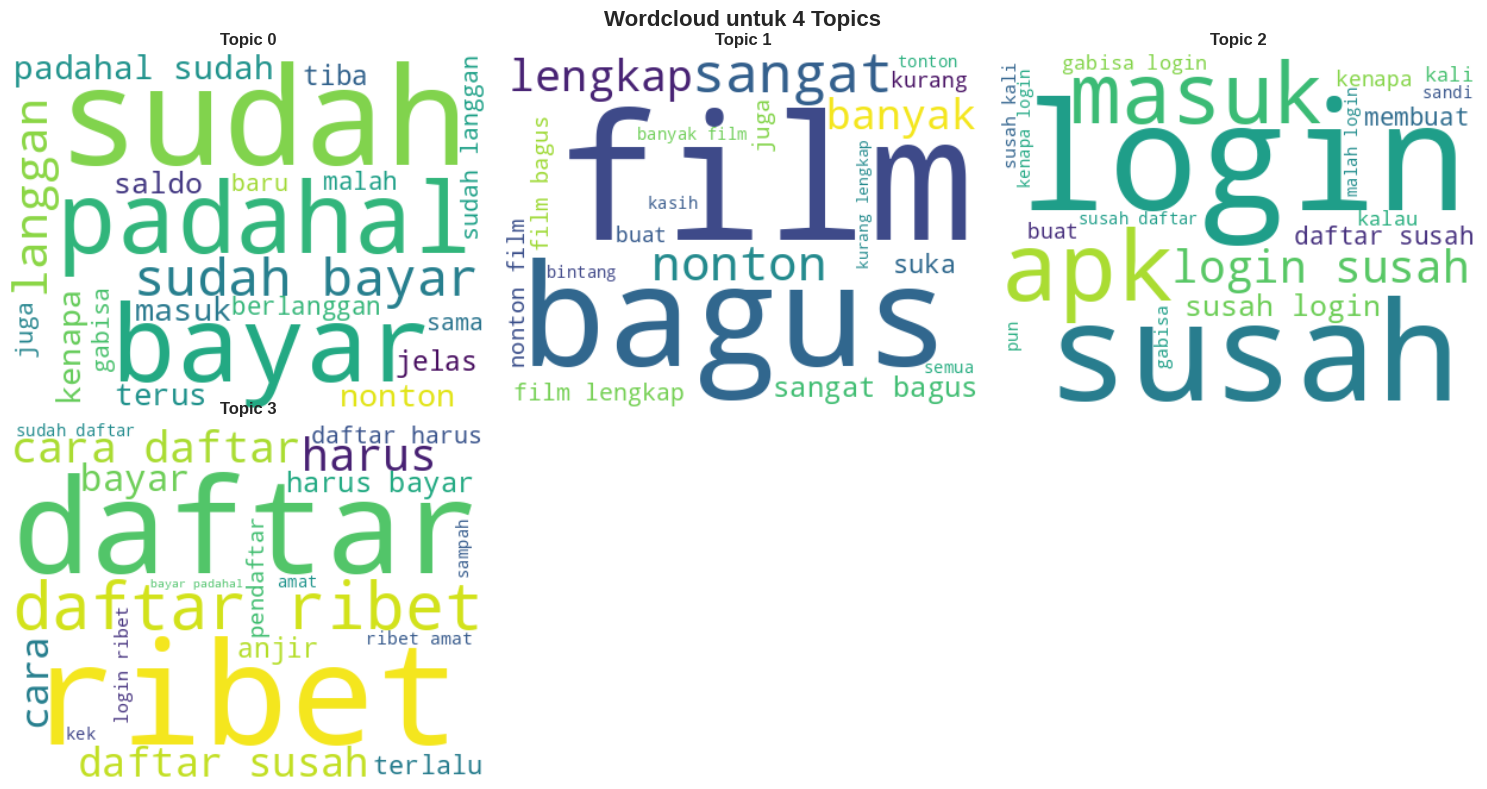

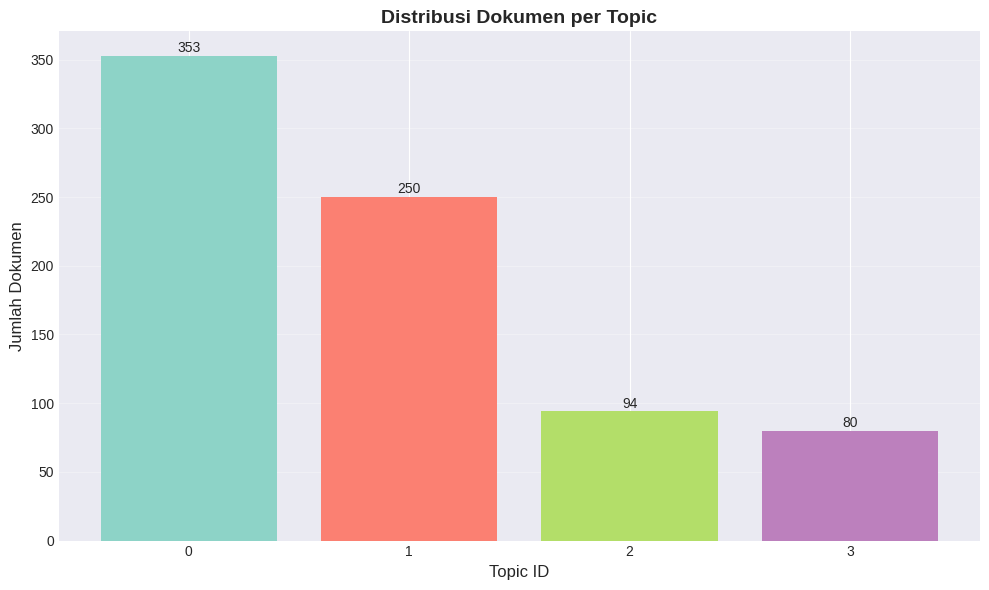


Topic Diversity Score: 0.9167
Average overlap per 10 top words: 0.83

PERBANDINGAN LDA vs NMF
Silhouette Score LDA: 0.0094
Silhouette Score NMF: 0.0171


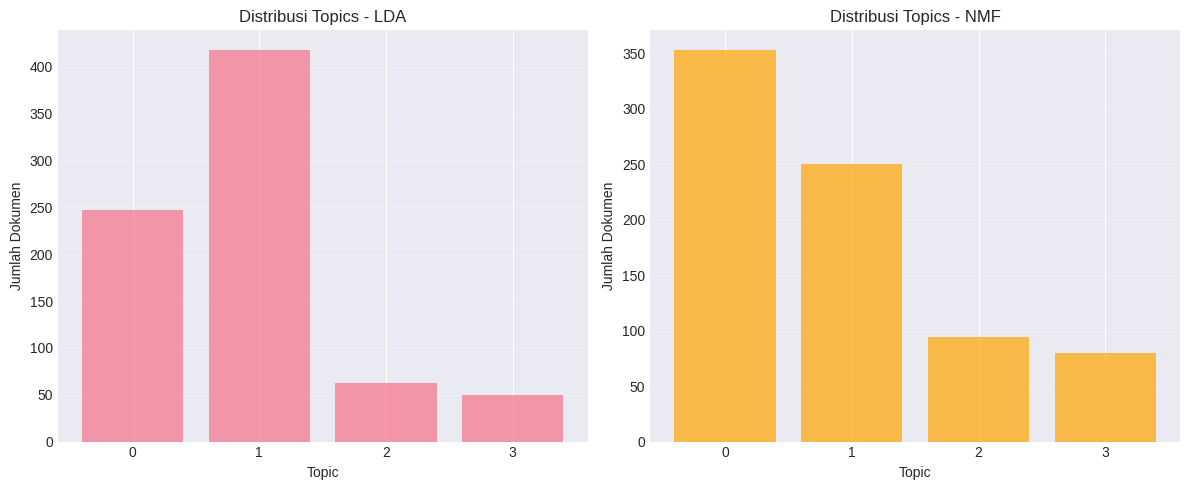


MENYIMPAN HASIL
Hasil topic modeling disimpan ke: hasil_topic_modeling.csv

SUMMARY HASIL TOPIC MODELING

Jumlah data: 777

LDA Topics:
  Jumlah topics: 4
  Distribusi: {0: np.int64(247), 1: np.int64(418), 2: np.int64(62), 3: np.int64(50)}

NMF Topics:
  Jumlah topics: 4
  Distribusi: {0: np.int64(353), 1: np.int64(250), 2: np.int64(94), 3: np.int64(80)}

CONTOH HASIL CLUSTERING PER TOPIC

LDA Topic 0 (Contoh 2 ulasan):
  1. halo selamat malam admin anime one piece episode kenapa mohon ditanggapi terima ...
  2. kualitas flim bagus sekali

LDA Topic 1 (Contoh 2 ulasan):
  1. sudah berhenti berlanggan masih saldo sya dikuras
  2. assala alaikum terhormat satu satu sangat jelek begitu download coba daftar pake...

LDA Topic 2 (Contoh 2 ulasan):
  1. payah dibuka percuma donload
  2. setiap nonton loading terus aneh

LDA Topic 3 (Contoh 2 ulasan):
  1. rating seberapa login susah minta ampun mahal bayar kocak pantes sepi
  2. tempat nonton paling favorit pokok

PROSES TOPIC MODELING SELE

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')
from wordcloud import WordCloud
from collections import Counter
import re

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ==============================================
# 1. LOAD DAN PREPROCESSING DATA
# ==============================================

def load_and_preprocess_data(file_path):
    """Load dan preprocessing data teks"""

    # Load data
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding='latin-1')

    print(f"Data berhasil dimuat. Jumlah data: {len(df)}")

    # Pastikan kolom ulasan ada
    if 'Ulasan_Bersih' not in df.columns:
        first_col = df.columns[0]
        df.rename(columns={first_col: 'Ulasan_Bersih'}, inplace=True)

    # Preprocessing teks
    def clean_text(text):
        if not isinstance(text, str):
            return ""

        # Konversi ke lowercase
        text = text.lower()

        # Hapus karakter spesial dan angka (opsional)
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Hapus whitespace berlebih
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    df['text_cleaned'] = df['Ulasan_Bersih'].apply(clean_text)

    # Hapus dokumen kosong
    df = df[df['text_cleaned'].str.len() > 10]
    print(f"Jumlah data setelah cleaning: {len(df)}")

    return df

# ==============================================
# 2. FEATURE EXTRACTION
# ==============================================

def create_vectorizers(texts, max_features=1000, use_tfidf=True):
    """Membuat vectorizer untuk topic modeling"""

    if use_tfidf:
        # TF-IDF Vectorizer untuk NMF
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=2,
            max_df=0.95,
            stop_words=None,  # Bisa ditambahkan stopwords
            ngram_range=(1, 2)
        )
        X = vectorizer.fit_transform(texts)
        print(f"Dimensi TF-IDF matrix: {X.shape}")

    else:
        # Count Vectorizer untuk LDA
        vectorizer = CountVectorizer(
            max_features=max_features,
            min_df=2,
            max_df=0.95,
            stop_words=None,
            ngram_range=(1, 2)
        )
        X = vectorizer.fit_transform(texts)
        print(f"Dimensi Count matrix: {X.shape}")

    return X, vectorizer

# ==============================================
# 3. TOPIC MODELING DENGAN ELBOW METHOD
# ==============================================

def calculate_coherence_scores_lda(texts, vectorizer, n_topics_range, n_words=10):
    """Menghitung coherence score untuk LDA"""

    coherence_scores = []
    models = []

    for n_topics in n_topics_range:
        print(f"Training LDA dengan {n_topics} topics...")

        # Train LDA
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=42,
            learning_method='online',
            max_iter=50,
            learning_offset=50.
        )

        X = vectorizer.transform(texts)
        lda.fit(X)

        # Hitung coherence score
        score = calculate_topic_coherence(lda, vectorizer, texts, n_words)
        coherence_scores.append(score)
        models.append(lda)

        print(f"  Coherence Score: {score:.4f}")

    return coherence_scores, models

def calculate_coherence_scores_nmf(texts, vectorizer, n_topics_range, n_words=10):
    """Menghitung coherence score untuk NMF"""

    coherence_scores = []
    models = []

    for n_topics in n_topics_range:
        print(f"Training NMF dengan {n_topics} topics...")

        # Train NMF
        nmf = NMF(
            n_components=n_topics,
            random_state=42,
            max_iter=500,
            init='nndsvda'
        )

        X = vectorizer.transform(texts)
        nmf.fit(X)

        # Hitung coherence score
        score = calculate_topic_coherence(nmf, vectorizer, texts, n_words)
        coherence_scores.append(score)
        models.append(nmf)

        print(f"  Coherence Score: {score:.4f}")

    return coherence_scores, models

def calculate_topic_coherence(model, vectorizer, texts, n_words=10):
    """Menghitung topic coherence score"""

    feature_names = vectorizer.get_feature_names_out()
    coherence = 0

    # Dapatkan top words untuk setiap topic
    if hasattr(model, 'components_'):
        for topic_idx, topic in enumerate(model.components_):
            top_word_indices = topic.argsort()[:-n_words-1:-1]
            top_words = [feature_names[i] for i in top_word_indices]

            # Hitung pairwise PMI untuk top words (versi sederhana)
            topic_coherence = 0
            for i in range(len(top_words)):
                for j in range(i+1, len(top_words)):
                    # Hitung co-occurrence sederhana
                    word_i = top_words[i]
                    word_j = top_words[j]

                    count_i = sum(1 for text in texts if word_i in text)
                    count_j = sum(1 for text in texts if word_j in text)
                    count_ij = sum(1 for text in texts if word_i in text and word_j in text)

                    if count_i > 0 and count_j > 0 and count_ij > 0:
                        topic_coherence += np.log((count_ij * len(texts)) / (count_i * count_j))

            coherence += topic_coherence

    return coherence / len(model.components_) if len(model.components_) > 0 else 0

def find_optimal_topics_elbow(scores, n_topics_range):
    """Mencari jumlah topik optimal menggunakan metode elbow"""

    # Konversi ke array numpy
    scores = np.array(scores)

    # Hitung elbow point menggunakan metode Kneedle
    # Implementasi sederhana: cari titik dengan kurvatur maksimum
    if len(scores) > 3:
        # Hitung perbedaan kedua (second derivative)
        first_deriv = np.diff(scores)
        second_deriv = np.diff(first_deriv)

        # Normalisasi second derivative
        if np.max(np.abs(second_deriv)) > 0:
            second_deriv_norm = second_deriv / np.max(np.abs(second_deriv))

            # Cari titik dengan perubahan maksimum
            elbow_idx = np.argmax(np.abs(second_deriv_norm))

            # Adjust index karena kita kehilangan 2 titik dari differencing
            optimal_n_topics = n_topics_range[elbow_idx + 2]
        else:
            # Fallback: cari titik dengan improvement kurang dari threshold
            improvements = np.diff(scores) / scores[:-1]
            threshold = 0.05  # 5% improvement threshold
            elbow_idx = np.where(improvements < threshold)[0]

            if len(elbow_idx) > 0:
                optimal_n_topics = n_topics_range[elbow_idx[0] + 1]
            else:
                optimal_n_topics = n_topics_range[len(n_topics_range)//2]
    else:
        optimal_n_topics = n_topics_range[len(n_topics_range)//2]

    return optimal_n_topics

# ==============================================
# 4. VISUALISASI TOPIC MODELING
# ==============================================

def plot_elbow_curve(n_topics_range, scores, model_name):
    """Plot elbow curve untuk topic modeling"""

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(n_topics_range, scores, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Jumlah Topics', fontsize=12)
    plt.ylabel('Coherence Score', fontsize=12)
    plt.title(f'Elbow Method untuk {model_name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(n_topics_range)

    # Tandai elbow point
    optimal_n = find_optimal_topics_elbow(scores, n_topics_range)
    optimal_idx = list(n_topics_range).index(optimal_n)
    plt.scatter(optimal_n, scores[optimal_idx], color='red', s=200, zorder=5,
                label=f'Optimal: {optimal_n} topics')
    plt.legend()

    # Plot rate of change
    plt.subplot(1, 2, 2)
    improvements = np.diff(scores)
    plt.plot(n_topics_range[1:], improvements, 'ro-', linewidth=2, markersize=8)
    plt.xlabel('Jumlah Topics', fontsize=12)
    plt.ylabel('Improvement', fontsize=12)
    plt.title(f'Rate of Change - {model_name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    return optimal_n

def visualize_topics_wordcloud(model, vectorizer, n_topics, top_n_words=20):
    """Visualisasi topics menggunakan wordcloud"""

    feature_names = vectorizer.get_feature_names_out()

    fig, axes = plt.subplots(np.ceil(n_topics/3).astype(int), 3,
                             figsize=(15, 4*np.ceil(n_topics/3).astype(int)))
    axes = axes.flatten()

    for topic_idx, topic in enumerate(model.components_):
        if topic_idx >= len(axes):
            break

        # Dapatkan top words dan weights
        top_features_ind = topic.argsort()[:-top_n_words-1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        # Buat dictionary untuk wordcloud
        word_freq = {word: weight for word, weight in zip(top_features, weights)}

        # Buat wordcloud
        wordcloud = WordCloud(
            width=400,
            height=300,
            background_color='white',
            max_words=top_n_words,
            contour_width=1,
            contour_color='steelblue'
        ).generate_from_frequencies(word_freq)

        axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
        axes[topic_idx].set_title(f'Topic {topic_idx}', fontsize=12, fontweight='bold')
        axes[topic_idx].axis('off')

    # Sembunyikan axes yang tidak terpakai
    for i in range(topic_idx + 1, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f'Wordcloud untuk {n_topics} Topics', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_topic_distribution(topic_assignments, n_topics):
    """Plot distribusi topics"""

    plt.figure(figsize=(10, 6))

    # Hitung distribusi
    topic_counts = np.bincount(topic_assignments, minlength=n_topics)

    # Buat bar plot
    bars = plt.bar(range(n_topics), topic_counts,
                   color=plt.cm.Set3(np.arange(n_topics)/n_topics))

    # Tambahkan label
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.xlabel('Topic ID', fontsize=12)
    plt.ylabel('Jumlah Dokumen', fontsize=12)
    plt.title('Distribusi Dokumen per Topic', fontsize=14, fontweight='bold')
    plt.xticks(range(n_topics))
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# ==============================================
# 5. TOPIC ASSIGNMENT DAN CLUSTERING
# ==============================================

def assign_topics(model, X, method='dominant'):
    """Menentukan topic untuk setiap dokumen"""

    if method == 'dominant':
        # Gunakan topic dengan probabilitas tertinggi
        topic_distribution = model.transform(X)
        topic_assignments = topic_distribution.argmax(axis=1)

    elif method == 'threshold':
        # Gunakan threshold untuk soft assignment
        topic_distribution = model.transform(X)
        threshold = 0.2  # Threshold minimum
        topic_assignments = []

        for dist in topic_distribution:
            dominant_topics = np.where(dist > threshold)[0]
            if len(dominant_topics) > 0:
                # Jika ada multiple topics, ambil yang tertinggi
                topic_assignments.append(dominant_topics[np.argmax(dist[dominant_topics])])
            else:
                # Jika tidak ada yang melewati threshold, ambil yang tertinggi
                topic_assignments.append(np.argmax(dist))

    elif method == 'mixed':
        # Mixed assignment dengan weighting
        topic_distribution = model.transform(X)
        topic_assignments = topic_distribution.argmax(axis=1)

    return topic_assignments, topic_distribution

def visualize_topic_clusters(topic_vectors, topic_assignments, n_topics):
    """Visualisasi clustering topics dengan t-SNE"""

    print("Membuat visualisasi t-SNE untuk topic clusters...")

    # Reduksi dimensi dengan t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced_vectors = tsne.fit_transform(topic_vectors)

    # Plot hasil
    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        reduced_vectors[:, 0],
        reduced_vectors[:, 1],
        c=topic_assignments,
        cmap='tab20',
        alpha=0.7,
        s=50,
        edgecolors='w',
        linewidth=0.5
    )

    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.title('Visualisasi Topic Clusters dengan t-SNE', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Topic')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return reduced_vectors

# ==============================================
# 6. ANALISIS DAN INTERPRETASI TOPICS
# ==============================================

def analyze_topics(model, vectorizer, texts, n_top_words=15):
    """Analisis dan interpretasi topics"""

    feature_names = vectorizer.get_feature_names_out()

    print("\n" + "="*60)
    print("ANALISIS TOPICS")
    print("="*60)

    topics_info = []

    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[:-n_top_words-1:-1]
        top_words = [feature_names[i] for i in top_word_indices]
        top_weights = topic[top_word_indices]

        print(f"\nTopic {topic_idx}:")
        print(f"  Top words: {', '.join(top_words[:10])}")

        # Cari dokumen representative untuk topic ini
        if hasattr(model, 'transform'):
            topic_distribution = model.transform(vectorizer.transform(texts))
            if topic_distribution.shape[1] > topic_idx:
                doc_scores = topic_distribution[:, topic_idx]
                top_doc_indices = doc_scores.argsort()[-3:][::-1]

                print(f"  Dokumen representative:")
                for i, idx in enumerate(top_doc_indices[:2]):
                    if idx < len(texts):
                        preview = texts[idx][:80] + "..." if len(texts[idx]) > 80 else texts[idx]
                        print(f"    {i+1}. {preview}")

        topics_info.append({
            'topic_id': topic_idx,
            'top_words': top_words,
            'top_weights': top_weights
        })

    return topics_info

def calculate_topic_diversity(model, vectorizer, top_n=10):
    """Menghitung diversity antar topics"""

    feature_names = vectorizer.get_feature_names_out()
    all_top_words = []

    for topic in model.components_:
        top_word_indices = topic.argsort()[:-top_n-1:-1]
        top_words = set([feature_names[i] for i in top_word_indices])
        all_top_words.append(top_words)

    # Hitung overlap antar topics
    overlaps = []
    for i in range(len(all_top_words)):
        for j in range(i+1, len(all_top_words)):
            overlap = len(all_top_words[i].intersection(all_top_words[j]))
            overlaps.append(overlap)

    avg_overlap = np.mean(overlaps) if overlaps else 0
    diversity = 1 - (avg_overlap / top_n)  # Normalisasi

    print(f"\nTopic Diversity Score: {diversity:.4f}")
    print(f"Average overlap per {top_n} top words: {avg_overlap:.2f}")

    return diversity

# ==============================================
# 7. FUNGSI UTAMA: LDA DENGAN ELBOW
# ==============================================

def lda_topic_modeling_with_elbow(df, max_topics=10):
    """LDA Topic Modeling dengan metode elbow"""

    print("\n" + "="*60)
    print("LDA TOPIC MODELING DENGAN METODE ELBOW")
    print("="*60)

    texts = df['text_cleaned'].tolist()

    # 1. Buat vectorizer (CountVectorizer untuk LDA)
    X_count, count_vectorizer = create_vectorizers(texts, max_features=800, use_tfidf=False)

    # 2. Tentukan range jumlah topics
    n_topics_range = range(2, max_topics + 1)

    # 3. Hitung coherence scores untuk setiap jumlah topics
    print("\nMenghitung coherence scores untuk berbagai jumlah topics...")
    coherence_scores, lda_models = calculate_coherence_scores_lda(
        texts, count_vectorizer, n_topics_range
    )

    # 4. Plot elbow curve dan temukan optimal topics
    print("\nMencari jumlah topics optimal...")
    optimal_n_topics = plot_elbow_curve(n_topics_range, coherence_scores, "LDA")

    print(f"\nJumlah topics optimal berdasarkan elbow method: {optimal_n_topics}")

    # 5. Gunakan model dengan topics optimal
    optimal_idx = list(n_topics_range).index(optimal_n_topics)
    optimal_lda = lda_models[optimal_idx]

    # 6. Assign topics ke dokumen
    X = count_vectorizer.transform(texts)
    topic_assignments, topic_distribution = assign_topics(optimal_lda, X)

    # 7. Tambahkan informasi topic ke dataframe
    df_result = df.copy()
    df_result['lda_topic'] = topic_assignments
    df_result['topic_probability'] = topic_distribution.max(axis=1)

    # 8. Analisis topics
    topics_info = analyze_topics(optimal_lda, count_vectorizer, texts)

    # 9. Visualisasi
    print("\nMembuat visualisasi...")
    visualize_topics_wordcloud(optimal_lda, count_vectorizer, optimal_n_topics)
    plot_topic_distribution(topic_assignments, optimal_n_topics)

    # 10. Hitung diversity score
    calculate_topic_diversity(optimal_lda, count_vectorizer)

    return df_result, optimal_lda, count_vectorizer, topics_info

# ==============================================
# 8. FUNGSI UTAMA: NMF DENGAN ELBOW
# ==============================================

def nmf_topic_modeling_with_elbow(df, max_topics=10):
    """NMF Topic Modeling dengan metode elbow"""

    print("\n" + "="*60)
    print("NMF TOPIC MODELING DENGAN METODE ELBOW")
    print("="*60)

    texts = df['text_cleaned'].tolist()

    # 1. Buat vectorizer (TF-IDF untuk NMF)
    X_tfidf, tfidf_vectorizer = create_vectorizers(texts, max_features=800, use_tfidf=True)

    # 2. Tentukan range jumlah topics
    n_topics_range = range(2, max_topics + 1)

    # 3. Hitung coherence scores untuk setiap jumlah topics
    print("\nMenghitung coherence scores untuk berbagai jumlah topics...")
    coherence_scores, nmf_models = calculate_coherence_scores_nmf(
        texts, tfidf_vectorizer, n_topics_range
    )

    # 4. Plot elbow curve dan temukan optimal topics
    print("\nMencari jumlah topics optimal...")
    optimal_n_topics = plot_elbow_curve(n_topics_range, coherence_scores, "NMF")

    print(f"\nJumlah topics optimal berdasarkan elbow method: {optimal_n_topics}")

    # 5. Gunakan model dengan topics optimal
    optimal_idx = list(n_topics_range).index(optimal_n_topics)
    optimal_nmf = nmf_models[optimal_idx]

    # 6. Assign topics ke dokumen
    X = tfidf_vectorizer.transform(texts)
    topic_assignments, topic_distribution = assign_topics(optimal_nmf, X)

    # 7. Tambahkan informasi topic ke dataframe
    df_result = df.copy()
    df_result['nmf_topic'] = topic_assignments
    df_result['topic_probability'] = topic_distribution.max(axis=1)

    # 8. Analisis topics
    topics_info = analyze_topics(optimal_nmf, tfidf_vectorizer, texts)

    # 9. Visualisasi
    print("\nMembuat visualisasi...")
    visualize_topics_wordcloud(optimal_nmf, tfidf_vectorizer, optimal_n_topics)
    plot_topic_distribution(topic_assignments, optimal_n_topics)

    # 10. Hitung diversity score
    calculate_topic_diversity(optimal_nmf, tfidf_vectorizer)

    return df_result, optimal_nmf, tfidf_vectorizer, topics_info

# ==============================================
# 9. COMPARISON DAN EVALUASI MODEL
# ==============================================

def compare_topic_models(df_lda, df_nmf, texts):
    """Membandingkan hasil LDA dan NMF"""

    print("\n" + "="*60)
    print("PERBANDINGAN LDA vs NMF")
    print("="*60)

    # Hitung silhouette score jika memungkinkan
    try:
        # Untuk perbandingan, kita butuh feature vectors
        from sklearn.feature_extraction.text import TfidfVectorizer

        vectorizer = TfidfVectorizer(max_features=500)
        X = vectorizer.fit_transform(texts)

        # Silhouette score untuk LDA topics
        if 'lda_topic' in df_lda.columns:
            lda_silhouette = silhouette_score(X, df_lda['lda_topic'].values)
            print(f"Silhouette Score LDA: {lda_silhouette:.4f}")

        # Silhouette score untuk NMF topics
        if 'nmf_topic' in df_nmf.columns:
            nmf_silhouette = silhouette_score(X, df_nmf['nmf_topic'].values)
            print(f"Silhouette Score NMF: {nmf_silhouette:.4f}")

    except Exception as e:
        print(f"Tidak dapat menghitung silhouette score: {e}")

    # Bandingkan distribusi topics
    if 'lda_topic' in df_lda.columns and 'nmf_topic' in df_nmf.columns:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        lda_counts = df_lda['lda_topic'].value_counts().sort_index()
        plt.bar(lda_counts.index.astype(str), lda_counts.values, alpha=0.7, label='LDA')
        plt.xlabel('Topic')
        plt.ylabel('Jumlah Dokumen')
        plt.title('Distribusi Topics - LDA')
        plt.grid(True, alpha=0.3, axis='y')

        plt.subplot(1, 2, 2)
        nmf_counts = df_nmf['nmf_topic'].value_counts().sort_index()
        plt.bar(nmf_counts.index.astype(str), nmf_counts.values, alpha=0.7, color='orange', label='NMF')
        plt.xlabel('Topic')
        plt.ylabel('Jumlah Dokumen')
        plt.title('Distribusi Topics - NMF')
        plt.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

# ==============================================
# 10. FUNGSI UTAMA PROGRAM
# ==============================================

def main():
    """Fungsi utama untuk menjalankan topic modeling clustering"""

    print("="*70)
    print("TOPIC MODELING CLUSTERING DENGAN METODE ELBOW")
    print("="*70)

    # 1. Load dan preprocessing data
    file_path = "Data Ulasan Bersih.csv"  # Sesuaikan dengan path file Anda
    df = load_and_preprocess_data(file_path)

    # Tampilkan sampel data
    print("\nSampel data setelah cleaning:")
    print(df[['Ulasan_Bersih', 'text_cleaned']].head(5))

    # 2. Jalankan LDA Topic Modeling dengan elbow method
    print("\n" + "="*70)
    print("MULAI PROSES LDA TOPIC MODELING")
    print("="*70)

    df_lda, lda_model, lda_vectorizer, lda_topics_info = lda_topic_modeling_with_elbow(
        df, max_topics=10
    )

    # 3. Jalankan NMF Topic Modeling dengan elbow method
    print("\n" + "="*70)
    print("MULAI PROSES NMF TOPIC MODELING")
    print("="*70)

    df_nmf, nmf_model, nmf_vectorizer, nmf_topics_info = nmf_topic_modeling_with_elbow(
        df, max_topics=10
    )

    # 4. Bandingkan hasil LDA dan NMF
    compare_topic_models(df_lda, df_nmf, df['text_cleaned'].tolist())

    # 5. Simpan hasil
    print("\n" + "="*70)
    print("MENYIMPAN HASIL")
    print("="*70)

    # Gabungkan hasil dari kedua metode
    df_final = df.copy()
    if 'lda_topic' in df_lda.columns:
        df_final['lda_topic'] = df_lda['lda_topic']
        df_final['lda_topic_prob'] = df_lda['topic_probability']

    if 'nmf_topic' in df_nmf.columns:
        df_final['nmf_topic'] = df_nmf['nmf_topic']
        df_final['nmf_topic_prob'] = df_nmf['topic_probability']

    # Simpan ke CSV
    output_file = "hasil_topic_modeling.csv"
    df_final.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Hasil topic modeling disimpan ke: {output_file}")

    # 6. Tampilkan summary
    print("\n" + "="*70)
    print("SUMMARY HASIL TOPIC MODELING")
    print("="*70)

    print(f"\nJumlah data: {len(df_final)}")

    if 'lda_topic' in df_final.columns:
        print(f"\nLDA Topics:")
        print(f"  Jumlah topics: {df_final['lda_topic'].nunique()}")
        print(f"  Distribusi: {dict(df_final['lda_topic'].value_counts().sort_index())}")

    if 'nmf_topic' in df_final.columns:
        print(f"\nNMF Topics:")
        print(f"  Jumlah topics: {df_final['nmf_topic'].nunique()}")
        print(f"  Distribusi: {dict(df_final['nmf_topic'].value_counts().sort_index())}")

    # 7. Tampilkan contoh hasil clustering
    print("\n" + "="*70)
    print("CONTOH HASIL CLUSTERING PER TOPIC")
    print("="*70)

    if 'lda_topic' in df_final.columns:
        for topic in sorted(df_final['lda_topic'].unique()):
            topic_data = df_final[df_final['lda_topic'] == topic]
            print(f"\nLDA Topic {topic} (Contoh 2 ulasan):")
            for i, (_, row) in enumerate(topic_data.head(2).iterrows()):
                text = row['Ulasan_Bersih']
                preview = text[:80] + "..." if len(text) > 80 else text
                print(f"  {i+1}. {preview}")

    print("\n" + "="*70)
    print("PROSES TOPIC MODELING SELESAI")
    print("="*70)

    return df_final, lda_model, nmf_model

# ==============================================
# 11. FUNGSI TAMBAHAN: EVALUASI KOMPREHENSIF
# ==============================================

def comprehensive_evaluation(df, model, vectorizer, model_type='lda'):
    """Evaluasi komprehensif untuk topic modeling"""

    texts = df['text_cleaned'].tolist()
    X = vectorizer.transform(texts)

    # 1. Dapatkan topic assignments
    topic_assignments, topic_distribution = assign_topics(model, X)

    # 2. Hitung berbagai metrics
    print(f"\nEvaluasi {model_type.upper()}:")

    # Topic coherence
    coherence = calculate_topic_coherence(model, vectorizer, texts)
    print(f"  Topic Coherence: {coherence:.4f}")

    # Topic diversity
    diversity = calculate_topic_diversity(model, vectorizer)
    print(f"  Topic Diversity: {diversity:.4f}")

    # Balance score (berapa merata distribusi topics)
    topic_counts = np.bincount(topic_assignments)
    balance_score = 1 - (np.std(topic_counts) / np.mean(topic_counts) if np.mean(topic_counts) > 0 else 1)
    print(f"  Balance Score: {balance_score:.4f}")

    # Overall quality score (gabungan metrics)
    quality_score = (coherence + diversity + balance_score) / 3
    print(f"  Overall Quality Score: {quality_score:.4f}")

    return {
        'coherence': coherence,
        'diversity': diversity,
        'balance': balance_score,
        'quality': quality_score
    }

# ==============================================
# 12. JALANKAN PROGRAM
# ==============================================

if __name__ == "__main__":

    # Jalankan fungsi utama
    df_result, lda_model, nmf_model = main()

    # Opsional: Lakukan evaluasi komprehensif
    print("\n" + "="*70)
    print("EVALUASI KOMPREHENSIF")
    print("="*70)

    # Evaluasi LDA jika ada
    if 'lda_topic' in df_result.columns:
        # Buat vectorizer untuk LDA
        lda_vectorizer = CountVectorizer(max_features=800)
        texts = df_result['text_cleaned'].tolist()
        lda_vectorizer.fit(texts)

        # Evaluasi
        lda_metrics = comprehensive_evaluation(df_result, lda_model, lda_vectorizer, 'lda')

    print("\n" + "="*70)
    print("ANALISIS TOPIC BERDASARKAN KONTEN")
    print("="*70)

    # Analisis manual untuk interpretasi topics
    if 'lda_topic' in df_result.columns:
        print("\nInterpretasi Topics LDA:")
        for topic_id in sorted(df_result['lda_topic'].unique()):
            topic_docs = df_result[df_result['lda_topic'] == topic_id]['Ulasan_Bersih'].tolist()

            # Ekstrak kata-kata umum
            all_words = ' '.join(topic_docs).lower().split()
            common_words = Counter(all_words).most_common(10)

            print(f"\nTopic {topic_id}:")
            print(f"  Jumlah dokumen: {len(topic_docs)}")
            print(f"  Kata-kata umum: {[word for word, count in common_words[:5]]}")

            # Cari tema umum
            if len(topic_docs) > 0:
                sample_doc = topic_docs[0][:100] + "..." if len(topic_docs[0]) > 100 else topic_docs[0]
                print(f"  Contoh: {sample_doc}")